In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os 
import cv2
import PIL
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential


In [3]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos',origin=dataset_url, cache_dir='.', untar=True)

In [4]:
data_dir

'.\\datasets\\flower_photos'

In [5]:
import pathlib
data_dir = pathlib.Path(data_dir)
data_dir

WindowsPath('datasets/flower_photos')

In [6]:
image_count = len(list(data_dir.rglob('*.jpg')))
image_count

3670

In [7]:
roses = list(data_dir.rglob('roses/*'))
roses[:5]

[WindowsPath('datasets/flower_photos/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

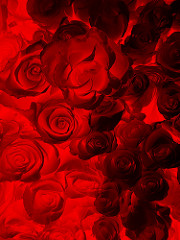

In [20]:
PIL.Image.open(str(roses[4]))

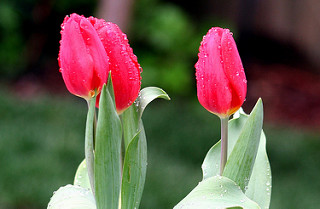

In [21]:
tulips = list(data_dir.rglob('tulips/*'))
PIL.Image.open(str(tulips[0]))

In [8]:
flowers_images_dict = {
    'roses':list(data_dir.rglob('roses/*')),
    'daisy':list(data_dir.rglob('daisy/*')),
    'dandelion':list(data_dir.rglob('dandelion/*')),
    'sunflowers':list(data_dir.rglob('sunflowers/*')),
    'tulips':list(data_dir.rglob('tulips/*'))
}

In [9]:
flowers_labels_dict = {
    'roses':0,
    'daisy':1,
    'dandelion':2,
    'sunflowers':3,
    'tulips':4,
}

In [10]:
str(flowers_images_dict['roses'][0])

'datasets\\flower_photos\\flower_photos\\roses\\10090824183_d02c613f10_m.jpg'

In [11]:
img = cv2.imread(str(flowers_images_dict['roses'][0]))
img.shape

(240, 179, 3)

In [38]:
cv2.resize(img,(180,180)).shape

(180, 180, 3)

In [12]:
x, y = [],[]
for flower_name, images in flowers_images_dict.items():
    for image in images:
        img=cv2.imread(str(image))
        resized_img = cv2.resize(img,(180,180))
        x.append(resized_img)
        y.append(flowers_labels_dict[flower_name])

In [16]:
y[:5]

[0, 0, 0, 0, 0]

In [13]:
x= np.array(x)
y = np.array(y)

In [14]:

from sklearn.model_selection import train_test_split
X_train ,X_test, y_train, y_test = train_test_split(x,y,random_state=0)

In [15]:
x_train_scaled = X_train/255
x_test_scaled = X_test /255

In [45]:
x_train_scaled

array([[[[0.26666667, 0.30980392, 0.30196078],
         [0.24705882, 0.2745098 , 0.24705882],
         [0.23529412, 0.24313725, 0.21960784],
         ...,
         [0.19215686, 0.15686275, 0.14509804],
         [0.18823529, 0.15294118, 0.14117647],
         [0.18823529, 0.15294118, 0.14117647]],

        [[0.22352941, 0.24313725, 0.23529412],
         [0.23921569, 0.25098039, 0.23529412],
         [0.23529412, 0.23921569, 0.21568627],
         ...,
         [0.18823529, 0.15294118, 0.14117647],
         [0.18823529, 0.15294118, 0.14117647],
         [0.19607843, 0.16078431, 0.14901961]],

        [[0.23921569, 0.22745098, 0.22352941],
         [0.25098039, 0.25098039, 0.23137255],
         [0.23137255, 0.23137255, 0.20784314],
         ...,
         [0.19215686, 0.15686275, 0.14509804],
         [0.19215686, 0.15686275, 0.14509804],
         [0.19607843, 0.16078431, 0.14901961]],

        ...,

        [[0.19215686, 0.4745098 , 0.36470588],
         [0.15686275, 0.25490196, 0.2       ]

In [16]:
num_classes = 5

model = Sequential([
    layers.Conv2D(16,3,padding='same' ,activation='relu'),
    layers.MaxPool2D(),
    layers.Conv2D(32,3, padding='same',activation='relu'),
    layers.MaxPool2D(),
    layers.Conv2D(64,3, padding='same' ,activation='relu'),
    layers.MaxPool2D(),
    layers.Flatten(),
        layers.Dense(128,activation='relu'),
        layers.Dense(num_classes)

])

model.compile(optimizer='adam',loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=['accuracy']),




(None,)

In [ ]:
model.fit(x_train_scaled,y_train,epochs=10)

In [25]:
model.evaluate(x_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.2298 - loss: 1.6078


[1.6078006029129028, 0.2298474907875061]

In [27]:
prediction = model.predict(x_test_scaled)
prediction

29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 185ms/step


array([[-0.04803935,  0.02607483, -0.04177119, -0.0048557 ,  0.04699946],
       [-0.04723476,  0.01225946,  0.0592601 , -0.05919005,  0.10881889],
       [-0.03612199,  0.03174227,  0.04006554, -0.07062698,  0.06695683],
       ...,
       [-0.03890752,  0.01153429, -0.05164656, -0.03387257,  0.09033335],
       [-0.09434436,  0.05762819, -0.00733203, -0.05984996,  0.02668034],
       [-0.0658906 ,  0.06527162,  0.02187628, -0.00643302,  0.09563793]],
      shape=(918, 5), dtype=float32)

In [29]:
score = tf.nn.softmax(prediction[0])
np.argmax(score)

np.int64(4)

In [30]:
y_test[0]

np.int64(1)

Improve Test Accuracy Using Data Augmentation

In [19]:
data_augmentation = keras.Sequential(
    [
layers.RandomFlip("horizontal", input_shape=(180, 180, 3)),
layers.RandomRotation(0.1),
layers.RandomZoom(0.9),
    ]
)

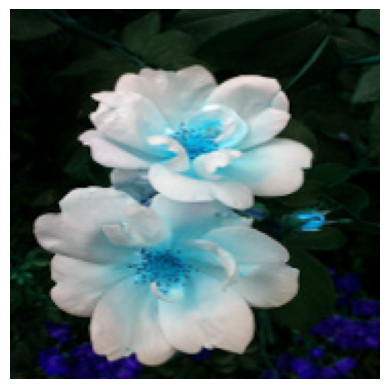

In [34]:
plt.axis('off')
plt.imshow(x[0])

Newly generated training using data augmentation

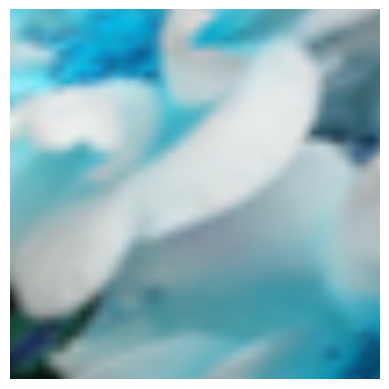

In [20]:
plt.axis('off')
plt.imshow(data_augmentation(x)[0].numpy().astype("uint8"))